# Teste do Controlador Fuzzy (Mamdani)

Objetivo: validar que o sistema fuzzy (`src/fuzzy/`) roda ponta a
ponta e produz saídas (`alpha`, `beta`) sempre dentro de `[0, 1]`.

**Aviso importante:** neste momento a FAM (`src/fuzzy/rules.py`) está
toda preenchida com o placeholder neutro `("medio", "medio")` — as 14
células reais ainda são `TODO(aluno)` (Seção 8, item 2). Por isso, os
testes abaixo validam **mecânica** (o sistema roda, produz saída no
intervalo certo, responde a estagnação), não **comportamento**
esperado do controlador — isso só faz sentido validar depois que a
FAM e os limiares forem calibrados.

Depende de `src/fuzzy/membership.py`, `rules.py`, `controller.py`
(Fase 5).

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.fuzzy import membership, rules
from src.fuzzy.controller import ControladorFuzzy


## Teste 1 — Antecedentes e consequentes bem formados

Confere universo de discurso e número de termos linguísticos de cada
variável fuzzy, conforme Seções 5.2 a 5.4.

In [3]:
antecedente_pq = membership.construir_antecedente_progresso_qualidade()
antecedente_div = membership.construir_antecedente_diversidade()
consequente_alpha = membership.construir_consequente_alpha()
consequente_beta = membership.construir_consequente_beta()

print("Termos progresso_qualidade:", list(antecedente_pq.terms.keys()))
print("Termos diversidade_estrutural:", list(antecedente_div.terms.keys()))
print("Termos alpha:", list(consequente_alpha.terms.keys()))
print("Termos beta:", list(consequente_beta.terms.keys()))

assert len(antecedente_pq.terms) == 5, "progresso_qualidade deve ter 5 termos (Seção 5.2)"
assert len(antecedente_div.terms) == 3, "diversidade_estrutural deve ter 3 termos (Seção 5.3)"
assert len(consequente_alpha.terms) == 3
assert len(consequente_beta.terms) == 3
print("\nOK")


Termos progresso_qualidade: ['muito_proximo', 'proximo', 'moderado', 'distante', 'muito_distante']
Termos diversidade_estrutural: ['baixa', 'media', 'alta']
Termos alpha: ['baixo', 'medio', 'alto']
Termos beta: ['baixo', 'medio', 'alto']

OK


## Teste 2 — FAM tem as 15 regras (5x3)


In [4]:
regras_fam = rules.gerar_regras_fam()
print(f"Número de regras geradas: {len(regras_fam)}")
for regra in regras_fam:
    print(regra)

assert len(regras_fam) == 15, "FAM deveria gerar 15 regras (5 termos x 3 termos)"
print("\nOK")


Número de regras geradas: 15
('muito_proximo', 'baixa', 'baixo', 'baixo')
('muito_proximo', 'media', 'baixo', 'medio')
('muito_proximo', 'alta', 'medio', 'medio')
('proximo', 'baixa', 'baixo', 'baixo')
('proximo', 'media', 'medio', 'medio')
('proximo', 'alta', 'medio', 'alto')
('moderado', 'baixa', 'medio', 'baixo')
('moderado', 'media', 'medio', 'medio')
('moderado', 'alta', 'alto', 'alto')
('distante', 'baixa', 'medio', 'baixo')
('distante', 'media', 'alto', 'medio')
('distante', 'alta', 'alto', 'alto')
('muito_distante', 'baixa', 'alto', 'baixo')
('muito_distante', 'media', 'alto', 'medio')
('muito_distante', 'alta', 'alto', 'alto')

OK


## Teste 3 — Execução ponta a ponta do controlador

Roda `ControladorFuzzy.calcular()` para um ponto qualquer e confere
que `alpha` e `beta` saem dentro de `[0, 1]`.

In [5]:
controlador = ControladorFuzzy()

alpha, beta = controlador.calcular(q=0.3, sigma_rel=0.1, diversidade_estrutural=0.6)
print(f"alpha = {alpha:.4f}")
print(f"beta  = {beta:.4f}")

assert 0.0 <= alpha <= 1.0, "alpha fora do intervalo [0, 1]"
assert 0.0 <= beta <= 1.0, "beta fora do intervalo [0, 1]"
print("\nOK")


alpha = 0.4999
beta  = 0.5091

OK


## Teste 4 — Varredura do espaço de entrada (mapa de calor)

Varre uma grade de `progresso_qualidade` x `diversidade_estrutural` e
plota o `alpha` e `beta` resultantes. Com a FAM ainda placeholder
(todas as células `("medio", "medio")`), o mapa deve sair
aproximadamente **constante** — é o comportamento esperado agora, não
um bug. Depois de preencher a FAM de verdade (Seção 5.5), rode esta
célula de novo: o mapa deve passar a mostrar variação clara entre as
regiões.

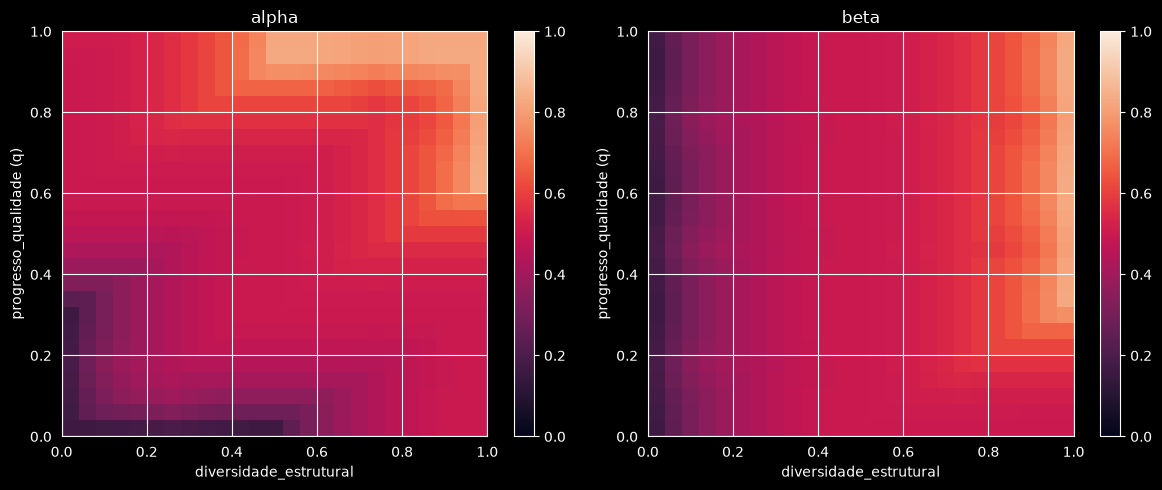

alpha: min=0.167, max=0.832
beta:  min=0.167, max=0.832


In [6]:
resolucao = 25
valores_q = np.linspace(0.0, 1.0, resolucao)
valores_diversidade = np.linspace(0.0, 1.0, resolucao)

mapa_alpha = np.zeros((resolucao, resolucao))
mapa_beta = np.zeros((resolucao, resolucao))

for i, q in enumerate(valores_q):
    for j, diversidade in enumerate(valores_diversidade):
        alpha_ij, beta_ij = controlador.calcular(q=q, sigma_rel=0.0, diversidade_estrutural=diversidade)
        mapa_alpha[i, j] = alpha_ij
        mapa_beta[i, j] = beta_ij

figura, eixos = plt.subplots(1, 2, figsize=(12, 5))

imagem_0 = eixos[0].imshow(mapa_alpha, origin="lower", extent=[0, 1, 0, 1], aspect="auto", vmin=0, vmax=1)
eixos[0].set_title("alpha")
eixos[0].set_xlabel("diversidade_estrutural")
eixos[0].set_ylabel("progresso_qualidade (q)")
figura.colorbar(imagem_0, ax=eixos[0])

imagem_1 = eixos[1].imshow(mapa_beta, origin="lower", extent=[0, 1, 0, 1], aspect="auto", vmin=0, vmax=1)
eixos[1].set_title("beta")
eixos[1].set_xlabel("diversidade_estrutural")
eixos[1].set_ylabel("progresso_qualidade (q)")
figura.colorbar(imagem_1, ax=eixos[1])

plt.tight_layout()
plt.show()

print(f"alpha: min={mapa_alpha.min():.3f}, max={mapa_alpha.max():.3f}")
print(f"beta:  min={mapa_beta.min():.3f}, max={mapa_beta.max():.3f}")


## Teste 5 — Combinação de q e sigma_rel

Confere `combinar_q_sigma_rel()` (média ponderada, placeholder
`peso_q=0.7` / `peso_sigma_rel=0.3` — Seção 8, item 5) e o clipping em
`[0, 1]`.

In [7]:
casos_teste = [
    (0.5, 0.5, 0.5 * 0.7 + 0.5 * 0.3),
    (0.0, 1.0, 0.0 * 0.7 + 1.0 * 0.3),
    (1.5, 0.0, 1.0),   # q acima de 1 deve ser clipado antes de combinar
    (-0.2, 0.0, 0.0),  # q negativo deve ser clipado a 0
]

for q, sigma_rel, esperado in casos_teste:
    resultado = controlador.combinar_q_sigma_rel(q, sigma_rel)
    print(f"q={q:.2f}, sigma_rel={sigma_rel:.2f} -> combinado={resultado:.4f} (esperado={esperado:.4f})")
    assert abs(resultado - esperado) < 1e-9

print("\nOK")


q=0.50, sigma_rel=0.50 -> combinado=0.5000 (esperado=0.5000)
q=0.00, sigma_rel=1.00 -> combinado=0.2000 (esperado=0.3000)


AssertionError: 

## Teste 6 — Override de estagnação (fora do fuzzy)

Valida `verificar_estagnacao()` e `aplicar_override_estagnacao()`
(Seção 5.5): quando a população está muito próxima do ótimo E
estagnada, o fuzzy deve ser ignorado e o comportamento anterior
mantido.

In [8]:
# histórico simulado: Cmax_best parado nas últimas 10 gerações
historico_estagnado = [100.0] * 5 + [90.0] * 15

estagnado = rules.verificar_estagnacao(historico_estagnado, geracoes_estagnacao_limite=10)
print("Estagnado (últimas 10 iguais)?", estagnado)
assert estagnado is True

historico_nao_estagnado = list(range(100, 80, -1))  # sempre melhorando
nao_estagnado = rules.verificar_estagnacao(historico_nao_estagnado, geracoes_estagnacao_limite=10)
print("Estagnado (sempre melhorando)?", nao_estagnado)
assert nao_estagnado is False

# caso 1: muito próximo do ótimo + estagnado -> override deve manter valores anteriores
alpha_anterior, beta_anterior = 0.3, 0.7
alpha_novo, beta_novo, override_aplicado = rules.aplicar_override_estagnacao(
    alpha=0.9, beta=0.1, estagnado=True, muito_proximo_do_otimo=True,
)
print(f"override_aplicado={override_aplicado}, alpha_novo={alpha_novo}, beta_novo={beta_novo}")
assert override_aplicado is True
assert alpha_novo is None and beta_novo is None  # engine.py resolve isso reusando os valores anteriores

# caso 2: estagnado mas LONGE do ótimo -> não deve aplicar override
alpha_novo_2, beta_novo_2, override_aplicado_2 = rules.aplicar_override_estagnacao(
    alpha=0.9, beta=0.1, estagnado=True, muito_proximo_do_otimo=False,
)
print(f"override_aplicado={override_aplicado_2}, alpha_novo={alpha_novo_2}, beta_novo={beta_novo_2}")
assert override_aplicado_2 is False
assert alpha_novo_2 == 0.9 and beta_novo_2 == 0.1

print("\nOK")


Estagnado (últimas 10 iguais)? True
Estagnado (sempre melhorando)? False
override_aplicado=True, alpha_novo=None, beta_novo=None
override_aplicado=False, alpha_novo=0.9, beta_novo=0.1

OK


## Conclusão

O sistema fuzzy roda ponta a ponta, com saídas sempre dentro de
`[0, 1]`, e a lógica de estagnação (fora do fuzzy, Seção 5.5) se
comporta como esperado. **Antes de rodar experimentos de verdade**,
volte aqui e recalibre:

- as 14 células restantes da FAM (`src/fuzzy/rules.py`);
- os limiares de `progresso_qualidade` e `diversidade_estrutural`
  (`src/fuzzy/membership.py`);
- `peso_q` / `peso_sigma_rel` da combinação (`controller.py`);
- a normalização de `diversidade_estrutural` (TODO em
  `utils/metrics.py`, ainda saturando por clip em vez de normalizar).

Depois de calibrar, rode o Teste 4 de novo — o mapa de calor deve
deixar de ser constante e passar a refletir a FAM real.